### **Figure 4.** Bar plots and topographies of relevant parameters (for gradiometers). 

In [3]:
"""
Script for Generating Figure 4 with Spectral Parameters in Barplots and Scalp Topographies.

This notebook can be used to generate the "Figure 4" of the paper. It reads source
data that was stored in the data directory of this repository (generated with figure04_source_data.ipynb). The figure shows barplots with mean values and SEM of spectral parameters (exponent, and power in theta, alpha, and beta bands) for each age group and phase, with individual lines connecting the two phases for each subject. It also shows the mean topographic distributions of each spectral parameter across subjects and phases, plotted onto the MEG sensor layout.

Author: Maité Crespo García
Affiliation: MRC Cognition and Brain Sciences Unit, Cambridge, UK
Date: 2026 (last modified)
"""

import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
import seaborn as sns
import os

print(os.getcwd())
datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Main directory: {datadir}')

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

# ---- File with subjects and age in each phase ----
agefile = os.path.join(datadir,f'meglong_rest_age.tsv')

megtype = 'grad' # 'grad', 'mag',
age_groups = ['Young', 'Middle', 'Old']

# --- Read in the subjects and age dataframes ---
subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
agedf = pd.read_csv(agefile, sep='\t', index_col=0)
agedf.rename(columns={'p2_meg_age': 'p2_age', 'p5_meg_age': 'p5_age'}, inplace=True)

subjects = subjectsdf.index.tolist()
agedf = agedf.loc[subjects]
subjectsdf = subjectsdf.loc[subjects]

# --- Define age groups based on age in phase 2
age_bins = np.percentile(agedf['p2_age'], [0, 100/3, 2*100/3, 100])
subjectsdf['Age_group'] = pd.cut(agedf['p2_age'], bins=age_bins, labels=['Young', 'Middle', 'Old'], include_lowest=True)
agedf.loc[subjects, 'Age_group'] = subjectsdf.loc[subjects, 'Age_group']

# Generate structural summary metrics without using loops
summary_df = agedf.groupby('Age_group', observed=True).agg(
    min_age=('p2_age', 'min'),
    max_age=('p2_age', 'max'),
    min_age_p5=('p5_age', 'min'),
    max_age_p5=('p5_age', 'max'),
    n_subjects=('p2_age', 'count')
)

# Convert directly to a dictionary matching your original schema
age_groups_dict = summary_df.to_dict(orient='index')

print(age_groups_dict)

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'royalblue'},
    'p5': {'label': 'Phase 5', 'color': 'orange'}
}

/home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/results
Main directory: /home/mc06/Documents/CamCAN/code/camcan_meglongrest_specparamlme_2026/data
{'Young': {'min_age': 24.3, 'max_age': 47.6, 'min_age_p5': 35.6, 'max_age_p5': 58.7, 'n_subjects': 45}, 'Middle': {'min_age': 47.8, 'max_age': 63.1, 'min_age_p5': 58.9, 'max_age_p5': 74.5, 'n_subjects': 44}, 'Old': {'min_age': 63.2, 'max_age': 84.1, 'min_age_p5': 70.9, 'max_age_p5': 95.5, 'n_subjects': 44}}


### **Figure 4**: bar plots with parameter means, LME estatistics, and topographies of power (3 columns)

/tmp/ipykernel_3143774/1951706034.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats['Effect'] = stats['Effect'].str.replace('Age0', 'A0').str.replace('deltaAge', 'dA')
/tmp/ipykernel_3143774/1951706034.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats['Effect'] = stats['Effect'].str.replace('Age0', 'A0').str.replace('deltaAge', 'dA')
/tmp/ipykernel_3143774/1951706034.py:146: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

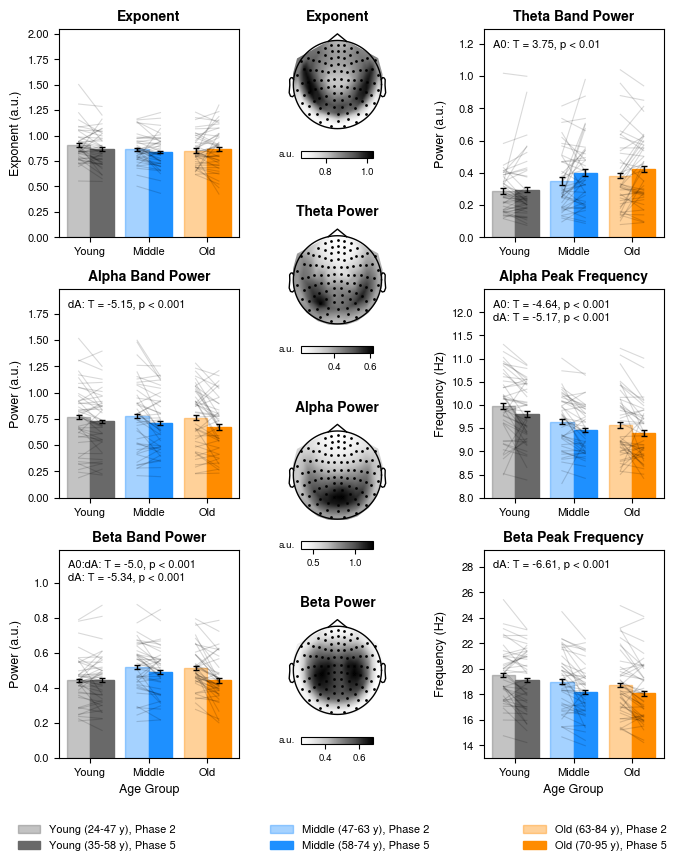

In [4]:
# Figure 4: Barplots of aperiodic and band parameters and topographies (full page, 3 columns - topographies with power only)
fitting_param = 'finley'

import starbars

bands = ['theta', 'alpha', 'beta'] #, 'gamma'
parameters = ['exponent']
for band in bands:
    if band not in ['gamma']:
        parameters.append(f'{band}_band_power')
    if band not in ['theta']:
        parameters.append(f'{band}_peak_freq')

# Define colors for each age group
age_group_colors = {
    'Young': 'dimgray',
    'Middle': 'dodgerblue',
    'Old': 'darkorange'
}

# ---- FUNCTIONS for plotting ----
def plot_topo(var, pos, vardict, ax):
    # Function to plot the topography for a given spectral parameter (var) on its corresponding
    # channel positions (pos), using the formatting parameters defined in vardict, on the axis ax.
    im, cm = mne.viz.plot_topomap(var, pos, mask=np.ones((len(var),), dtype=bool), mask_params={'markersize':2, 'marker':'.'}, 
    cmap=vardict['cmap'], vlim=vardict['vlim'], image_interp='linear',
    contours=0, ch_type='mag', axes=ax, sensors='k.', show=False)
    ax.set_title(vardict['title'], fontdict={'fontsize':10}, fontweight='bold')    
    return im


def plot_colorbar_horizontal(im, topo_ax, varunits, title=''):
    # Function to plot horizontal colorbar below the topography

    clb = plt.colorbar(mappable=im, ax=topo_ax, orientation='horizontal', location='bottom',  aspect=10, shrink=0.5) 
    clb.ax.tick_params(labelsize=7)
    clb.ax.set_ylabel(varunits, fontsize=7, rotation='horizontal', verticalalignment='center', labelpad=10) #

    cbox = clb.ax.get_position()
    clb.ax.set_position([cbox.x0-0.034, cbox.y0,
                 cbox.width,
                 cbox.height])


def plot_bars_lines_annotations(df_data, col_x, col_y, col_hue, ax, title=None, ylabel=None, xlabel=None, ylim=None, col_error=None, palette=None, indiv_values=None, annotations=None, stats=None):
    # Function to plot bars with individual lines and significance stars and p values

    sns.barplot(data=df_data, x=col_x, y=col_y, hue=col_hue, ax=ax)

    data_reordered = df_data.copy()
    data_reordered = data_reordered.loc[[0,2,4,1,3,5],:]# reorder to have p2 and p5 for each age group

    labels = [df_data.iloc[i][col_x] + ' (' + df_data.loc[i,'min_age'] + '-' +  df_data.loc[i,'max_age'] + ' y), ' + df_data.iloc[i][col_hue] for i in range(df_data.shape[0])]

    labels = [label.replace('p2', 'Phase 2').replace('p5', 'Phase 5') for label in labels]

    for bar, color in zip(ax.patches, data_reordered['Color']):
        bar.set_color(color)

    for bar, alpha in zip(ax.patches, data_reordered['Alpha']):
        bar.set_alpha(alpha)

    patches = [p for p in ax.patches if p.get_height() == p.get_height()]  # filters NaNs
    centers = np.array([p.get_x() + p.get_width() / 2 for p in patches])[0:6]
    heights = np.array([p.get_height() for p in patches])[0:6]

    yerr = df_data[col_error].to_numpy(float)
    yerr = yerr[[0,2,4,1,3,5]]

    capsize = 2

    ax.errorbar(
        centers, heights,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=capsize,
        capthick=1,
        zorder=10
    )

    # Plot individual lines
    if indiv_values is not None:
        # reorder indiv_values to match the order of bars
        indiv_values_reordered = []
        for i in [0,2,4,1,3,5]:
            indiv_values_reordered.append(indiv_values[i])
        
        for i in range(0, 3):  # for each age group
            for subj in indiv_values_reordered[i].keys():
                y_vals = []
                x_vals = []
                
                if subj in indiv_values_reordered[i] and subj in indiv_values_reordered[i+3]:
                    y_vals.append(indiv_values_reordered[i][subj])
                    x_vals.append(centers[i])
                    y_vals.append(indiv_values_reordered[i+3][subj])
                    x_vals.append(centers[i+3])
                    
                ax.plot(x_vals, y_vals, color='black', alpha=0.15, linewidth=0.8, zorder=5)

    ylim_ax = list(ax.get_ylim())

    if 'Freq' in title:
        ylim_ax[0] = ylim[0]

    ylim_ax[1] = ylim[1]

    if annotations is not None:
        starbars.draw_annotation(
            annotations,
            ax=ax,
            ns_show=False,
            bar_gap=0.02,
            
        )

    ax.set_ylim(tuple(ylim_ax))

    if 'Exponent' in ylabel:
        ax.legend_ = None

    elif 'Beta Band' in title:
        
        newpatches = [patches[i] for i in [0,3,1,4,2,5]]  # reorder to have p2 and p5 for each age group
        ax.legend(newpatches, labels, frameon=False, fontsize=8, bbox_to_anchor=(-0.25, -.2, 3.65, -.1), loc='upper left', mode="expand", borderaxespad=0., ncols=3)
    else:
        ax.legend_ = None
    
    if title is not None:
        ax.set_title(title, fontsize=10, fontweight='bold') 

    if ylabel is None:
        ylabel = col_y
    ax.set_ylabel(ylabel, fontsize=9) 

    if xlabel is None:
        xlabel = col_x
    ax.set_xlabel(xlabel, fontsize=9) 

    ax.tick_params(axis='both', which='major', labelsize=8) 

    if stats is not None:
        if stats.shape[0] > 0:
            stats['Effect'] = stats['Effect'].str.replace('Age0', 'A0').str.replace('deltaAge', 'dA')
            box_text = ''
            for j in range(stats.shape[0]):
                stat = stats.iloc[j]
                pvalue = stat['P']
                tvalue = stat['T'].round(2)

                if pvalue < 0.05:
                    if pvalue < 0.001:
                        pvalue_text = f'p < 0.001'
                    elif pvalue < 0.01:
                        pvalue_text = 'p < 0.01'
                    else:
                        pvalue_text = 'p < 0.05'

                    stat_text = f"T = {tvalue}, {pvalue_text}"
                    box_text += f"{stat['Effect']}: {stat_text}\n"
            
            box_text = box_text[:-1]  # remove the last newline character   

            bbox = dict(boxstyle='round', fc='white', ec='white', alpha=0)
            ax.text(0.05, 0.95, box_text, fontsize=8, bbox=bbox,
                    transform=ax.transAxes, horizontalalignment='left', verticalalignment='top', linespacing = 1.3)

# --- End of functions ----

####################################################################################################
# ---- Bar Plots Version 4: with individual lines (optional) and significance stars (optional) and legend with effects and p values ----

# General figure settings
plt.rcParams.update({'font.size': 10})
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]

from matplotlib.gridspec import GridSpec

# --- Create a figure with a GridSpec layout to accommodate the bar plots and topographies ---
fig = plt.figure(figsize=(7.2, 9))
gs = GridSpec(12, 3, width_ratios=[1, 0.8, 1], wspace=0.3, hspace=4, left=0.11, right=0.95, top=0.94, bottom=0.13)

ax1 = fig.add_subplot(gs[0:4, 0])
ax2top = fig.add_subplot(gs[0:3, 1])
ax2bottom = fig.add_subplot(gs[3:6, 1])
ax3 = fig.add_subplot(gs[0:4, 2])
ax4 = fig.add_subplot(gs[4:8, 0])
ax5 = fig.add_subplot(gs[6:9, 1])
ax6 = fig.add_subplot(gs[4:8, 2])
ax7 = fig.add_subplot(gs[8:12, 0])
ax8 = fig.add_subplot(gs[9:12, 1])
ax9 = fig.add_subplot(gs[8:12, 2])

axs = np.array([[ax1, ax2top, ax3],
                [ax4, ax5, ax6],
                [ax7, ax8, ax9]])

# This TSV file contains the results of the LME statistical tests for all spectral 
# parameters of Figure 4, to be plotted as text boxes in the bar plots with the 
# T and p values.
statsdf = pd.read_csv(os.path.join(datadir, f'figure04_{megtype}_stats.tsv'), sep='\t')

# This TSV file contains the values of all spectral parameter of figure 4 for each subject and phase. We will use it to plot the individual lines connecting the two phases for each subject in the bar plots.
df_vars = pd.read_csv(os.path.join(datadir, f'figure04_{megtype}_indiv_values.tsv'), sep='\t')

# Loop over parameters and create bar plots and topographies
for i, parameter in enumerate(parameters):
    
    ax_col = (i%2)*2  # column for bar plot
    ax_col_topo = 1  # column for topo plot
    ax_row = i//2  # row for both plots

    parameter_stats = statsdf[statsdf['Parameter'] == f'{parameter.replace('_', ' ').title()} ({megtype})']


    col_y = f'{parameter}_{megtype}'

    indiv_values = [] # list to save individual values for each subject and phase, to be plotted as lines connecting the two phases for each subject in the bar plots

    # Loop over age groups to calculate mean and SEM for each phase
    for age_group in age_groups:

        # Create list with subjects in the age group
        group_subjects = agedf[agedf['Age_group'] == age_group].index.tolist()

        # Loop over phases to calculate mean for each phase
        for phase in phases:
            # Create a temporary DataFrame for the age group and phase
            df_subset = df_vars[(df_vars['subject'].isin(group_subjects)) & (df_vars['phase'] == phase)]
            
            # Save individual values for each subject, to be plotted as lines connecting the two phases for each subject
            indiv_values.append(df_subset[[col_y, 'subject']].set_index('subject').to_dict()[col_y])

            
    # --- End of loop over age groups and phases, df_data is now ready for plotting

    # Reads the TSV file with the mean and SEM values for each parameter, age group, and phase, to be plotted as bars with error bars in the bar plot. We save it as a TSV file in the sandbox data directory to be used in the R version of the figure.
    df_data = pd.read_csv(os.path.join(datadir, f'figure04_{parameter}_{megtype}_barplot.tsv'), sep='\t')
    # Convert min and max age to string as the function expects it for the legend labels
    df_data['min_age'] = df_data['min_age'].astype(int).astype(str)
    df_data['max_age'] = df_data['max_age'].astype(int).astype(str)

    # Adjust y limits for each parameter, to take into account large individual values
    ylim = None
    if 'peak_freq' in parameter:
        if 'alpha' in parameter:
            ylim = [8, None]
        elif 'beta' in parameter:
            ylim = [13, None]
        elif 'gamma' in parameter:
            ylim = [30, None]
        else:
            ylim = [df_data['Mean'].mean()/2, None]
    else:
        ylim = [0, None]
    
    max_val = max([df_data['Mean'].max()] + [indiv_values[j][subj] for j in range(len(indiv_values)) for subj in indiv_values[j]])

    ylim[1] = max_val + (df_data['Mean'].max() - ylim[0])*0.6
    
    # Plot the barplot for each parameter
    plot_bars_lines_annotations(
        df_data=df_data,
        col_x='Age_group',
        col_y='Mean',
        col_hue='Phase',
        col_error='SEM',
        ax=axs[ax_row,ax_col],
        title=f'{parameter.replace("_", " ").replace('freq', 'frequency').title()}', #({megtype})
        ylabel='Frequency (Hz)' if 'peak_freq' in parameter else 'Power (a.u.)' if 'band_power' in parameter else 'Exponent (a.u.)',
        xlabel='Age Group' if i>=len(parameters)-2 else '',
        ylim=ylim,
        indiv_values=indiv_values,        
        stats=parameter_stats 
    )

    # Only plot topographies for exponent and bands power.
    if 'exponent' in parameter or 'power' in parameter:
        if 'theta' in parameter:
            ax_topo = ax2bottom
        else:
            ax_topo = axs[ax_row,ax_col_topo]

        # This TSV file contains the values of a spectral parameter averaged across 
        # subjects and phases, for each channel. We will use it to plot the topography 
        # of each parameter.
        df_topo = pd.read_csv(os.path.join(datadir, f'figure04_{parameter}_{megtype}_topo.tsv'), sep='\t')

        topovals = df_topo['Value'].to_numpy(float)
        pos = df_topo[['Position_x', 'Position_y']].to_numpy(float)        

        # Plot topography for the parameter
        im = plot_topo(
            var=topovals,
            pos=pos,
            vardict={
                'cmap': 'Greys',
                'vlim': (topovals.min(), topovals.max()),
                'title': parameter.replace('_', ' ').replace('band ', '').title()
            },
            ax=ax_topo
        )

        # Add horizontal colorbar below the topography
        plot_colorbar_horizontal(im, ax_topo, varunits='a.u.' if 'band_power' in parameter else 'Hz' if 'peak_freq' in parameter else 'a.u.')

        # Adjust position of the topography and colorbar to be better aligned to
        # the middle column of the figure
        topobox = ax_topo.get_position()
        ax_topo.set_position([topobox.x0-0.033, topobox.y0,
                    topobox.width,
                    topobox.height])

fig.align_ylabels(axs[:, 0])
fig.align_ylabels(axs[:, 2])

plt.savefig(os.path.join(f'Figure04.png'), dpi=300, format='png', transparent=False)
plt.show()